# QAOA Portfolio Optimization — Analysis

Phase 5.1: Four visualizations examining QAOA performance vs classical baselines.

1. **Approximation ratio vs circuit depth p** (for n=4 and n=6)
2. **Runtime vs portfolio size n** (QAOA vs brute-force vs heuristics)
3. **Measurement distribution histogram** (bitstring probabilities for n=4, p=1)
4. **Efficient frontier** with each method's solution marked

In [1]:
import sys
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from data.generate_data import load_assets, DEFAULT_TICKERS

# ── Load benchmark results ────────────────────────────────────────────────────
results_path = REPO_ROOT / "benchmarks" / "results" / "results.json"
with open(results_path) as f:
    results = json.load(f)

df = pd.DataFrame(results)
df["p"] = pd.to_numeric(df["p"], errors="coerce")

def _label(row):
    if row["solver"] == "qaoa_aer":
        return f"QAOA p={int(row['p'])}"
    return {"brute_force": "Brute Force",
            "greedy": "Greedy",
            "simulated_annealing": "Sim. Annealing"}.get(row["solver"], row["solver"])

df["solver_label"] = df.apply(_label, axis=1)

# ── Colour maps ───────────────────────────────────────────────────────────────
N_COLORS = {4: "#1976D2", 6: "#388E3C"}
SOLVER_COLORS = {
    "Brute Force":    "#1565C0",
    "Greedy":         "#2E7D32",
    "Sim. Annealing": "#E65100",
    "QAOA p=1":       "#6A1B9A",
    "QAOA p=2":       "#8E24AA",
    "QAOA p=3":       "#CE93D8",
}
SOLVER_ORDER = ["Brute Force", "Greedy", "Sim. Annealing", "QAOA p=1", "QAOA p=2", "QAOA p=3"]

matplotlib.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print(f"Loaded {len(df)} rows  |  n={sorted(df['n'].unique())}  |  solvers={sorted(df['solver'].unique())}")
df[["n", "p", "solver_label", "approx_ratio", "runtime"]].to_string(index=False)

Loaded 12 rows  |  n=[np.int64(4), np.int64(6)]  |  solvers=['brute_force', 'greedy', 'qaoa_aer', 'simulated_annealing']


' n   p   solver_label  approx_ratio  runtime\n 4 NaN    Brute Force      1.000000 0.000095\n 4 NaN         Greedy      1.000000 0.000038\n 4 NaN Sim. Annealing      1.000000 0.597320\n 4 1.0       QAOA p=1      1.000000 0.908307\n 4 2.0       QAOA p=2      1.680786 0.321452\n 4 3.0       QAOA p=3      1.143094 0.855747\n 6 NaN    Brute Force      1.000000 0.000590\n 6 NaN         Greedy      1.000000 0.000755\n 6 NaN Sim. Annealing      1.000000 0.610511\n 6 1.0       QAOA p=1      1.000000 0.218496\n 6 2.0       QAOA p=2      1.000000 0.900725\n 6 3.0       QAOA p=3      1.458782 1.051870'

## Plot 1 — Approximation Ratio vs Circuit Depth p

Shows how QAOA solution quality (relative to brute-force optimal) changes as circuit depth p increases.

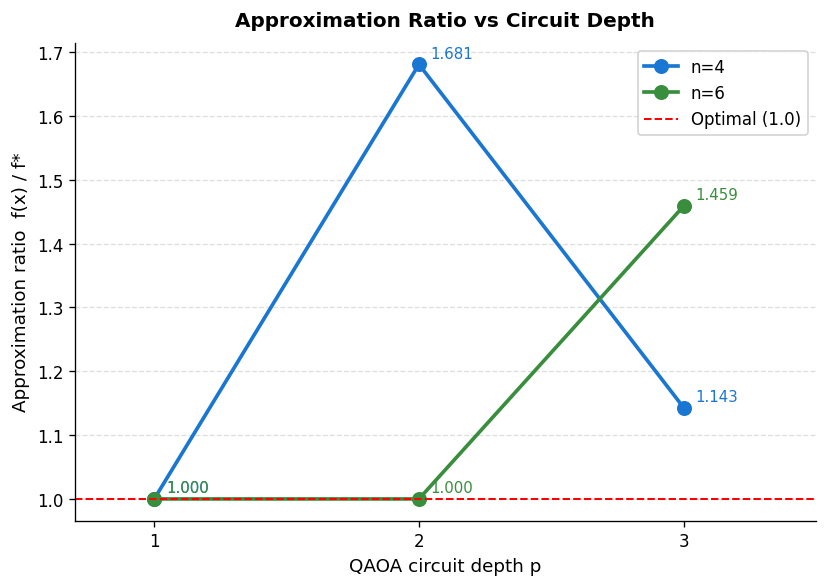

In [2]:
qaoa_df = df[df["solver"] == "qaoa_aer"].copy()
n_vals = sorted(qaoa_df["n"].unique().astype(int))

fig, ax = plt.subplots(figsize=(7, 5))

for n in n_vals:
    sub = qaoa_df[qaoa_df["n"] == n].sort_values("p")
    ax.plot(
        sub["p"], sub["approx_ratio"],
        color=N_COLORS[n], marker="o", linewidth=2.2,
        markersize=8, label=f"n={n}",
    )
    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['approx_ratio']:.3f}",
            (row["p"], row["approx_ratio"]),
            textcoords="offset points", xytext=(7, 4),
            fontsize=9, color=N_COLORS[n],
        )

ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="Optimal (1.0)")
ax.set_xlabel("QAOA circuit depth p", fontsize=11)
ax.set_ylabel("Approximation ratio  f(x) / f*", fontsize=11)
ax.set_title("Approximation Ratio vs Circuit Depth", fontweight="bold", pad=10)
ax.set_xticks([1, 2, 3])
ax.set_xlim(0.7, 3.5)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "fig1_approx_ratio_vs_depth.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 2 — Runtime vs Portfolio Size n

Compares wall-clock runtime across all solvers for each portfolio size.  QAOA runtimes are shown per depth p.

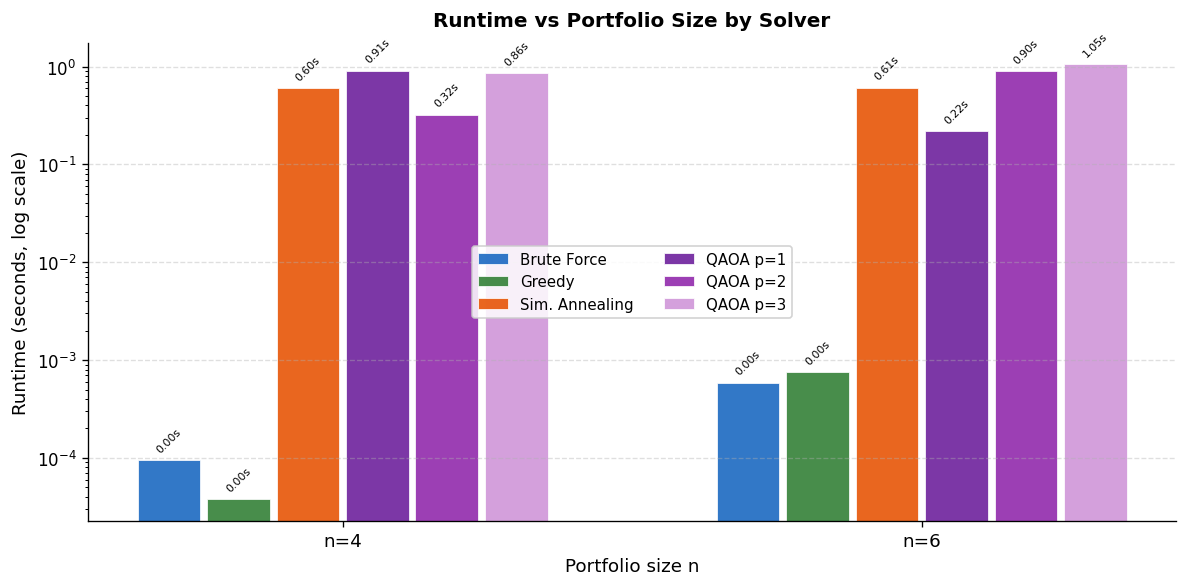

In [3]:
n_vals = sorted(df["n"].unique().astype(int))
solvers = [s for s in SOLVER_ORDER if s in df["solver_label"].unique()]

x = np.arange(len(n_vals))
n_s = len(solvers)
width = 0.12
offsets = np.linspace(-(n_s - 1) / 2, (n_s - 1) / 2, n_s) * width

fig, ax = plt.subplots(figsize=(10, 5))

for offset, solver in zip(offsets, solvers):
    vals = []
    for n in n_vals:
        row = df[(df["n"] == n) & (df["solver_label"] == solver)]
        vals.append(float(row["runtime"].values[0]) if not row.empty else np.nan)
    bars = ax.bar(
        x + offset, vals, width * 0.9,
        color=SOLVER_COLORS.get(solver, "#607D8B"),
        label=solver, alpha=0.88, edgecolor="white", linewidth=0.5,
    )
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v * 1.15,
                f"{v:.2f}s",
                ha="center", va="bottom", fontsize=6.5, rotation=45,
            )

ax.set_xticks(x)
ax.set_xticklabels([f"n={n}" for n in n_vals], fontsize=11)
ax.set_yscale("log")
ax.set_xlabel("Portfolio size n", fontsize=11)
ax.set_ylabel("Runtime (seconds, log scale)", fontsize=11)
ax.set_title("Runtime vs Portfolio Size by Solver", fontweight="bold", pad=10)
ax.legend(fontsize=9, framealpha=0.85, ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "fig2_runtime_vs_n.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 3 — Measurement Distribution Histogram (n=4, p=1)

Runs QAOA with the optimized parameters and plots the probability of each 4-qubit bitstring being measured.
The brute-force optimal bitstring is highlighted in red.

Running QAOA n=4, p=1 (seed=42, maxiter=300) …


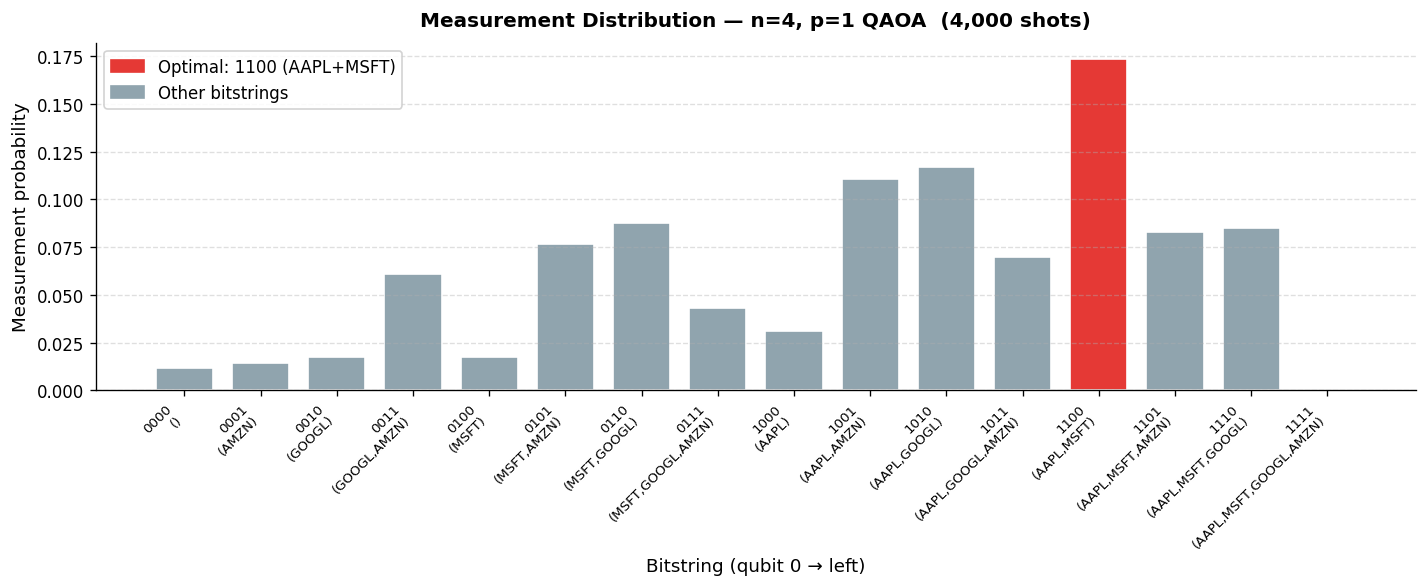

Optimal bitstring '1100' measured with probability: 0.173
Decoded selection: [1, 1, 0, 0]  obj=1.2492


In [4]:
from quantum.qaoa_runner import run_qaoa

tickers_4 = DEFAULT_TICKERS[:4]  # AAPL, MSFT, GOOGL, AMZN
mu4, Sigma4 = load_assets(tickers_4, REPO_ROOT / "data")

print("Running QAOA n=4, p=1 (seed=42, maxiter=300) …")
qaoa_result = run_qaoa(mu4, Sigma4, lam=1.0, k=2, p=1, shots=4000, seed=42, maxiter=300)
counts = qaoa_result.counts
total_shots = sum(counts.values())

# Qiskit keys are big-endian (qubit n-1 on left); reverse to little-endian
# to match the results.json convention (qubit 0 on left)
le_counts = {k[::-1]: v for k, v in counts.items()}

# Optimal bitstring from brute-force
optimal_bs = df[(df["n"] == 4) & (df["solver"] == "brute_force")]["bitstring"].values[0]

# Sort by descending count; all 2^4 = 16 bitstrings
all_bitstrings = ["".join(str(b) for b in x) for x in np.ndindex(*(2,) * 4)]
probs = [le_counts.get(bs, 0) / total_shots for bs in all_bitstrings]

colors = ["#E53935" if bs == optimal_bs else "#90A4AE" for bs in all_bitstrings]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(all_bitstrings)), probs, color=colors, width=0.75, edgecolor="white")

ax.set_xticks(range(len(all_bitstrings)))
ax.set_xticklabels(
    [f"{bs}\n({','.join(t for t, b in zip(tickers_4, bs) if b == '1')})"
     for bs in all_bitstrings],
    rotation=45, ha="right", fontsize=8,
)
ax.set_xlabel("Bitstring (qubit 0 → left)", fontsize=11)
ax.set_ylabel("Measurement probability", fontsize=11)
ax.set_title(
    f"Measurement Distribution — n=4, p=1 QAOA  ({total_shots:,} shots)",
    fontweight="bold", pad=10,
)

handles = [
    mpatches.Patch(color="#E53935", label=f"Optimal: {optimal_bs} (AAPL+MSFT)"),
    mpatches.Patch(color="#90A4AE", label="Other bitstrings"),
]
ax.legend(handles=handles, fontsize=10, framealpha=0.85)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "fig3_measurement_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

opt_prob = le_counts.get(optimal_bs, 0) / total_shots
print(f"Optimal bitstring '{optimal_bs}' measured with probability: {opt_prob:.3f}")
print(f"Decoded selection: {qaoa_result.bitstring.astype(int).tolist()}  obj={qaoa_result.objective:.4f}")

## Plot 4 — Efficient Frontier

Enumerates all C(n, k) feasible portfolios and plots them in (variance, return) space.
Each solver's selected portfolio is marked; the Pareto frontier (min variance per return level) is drawn.

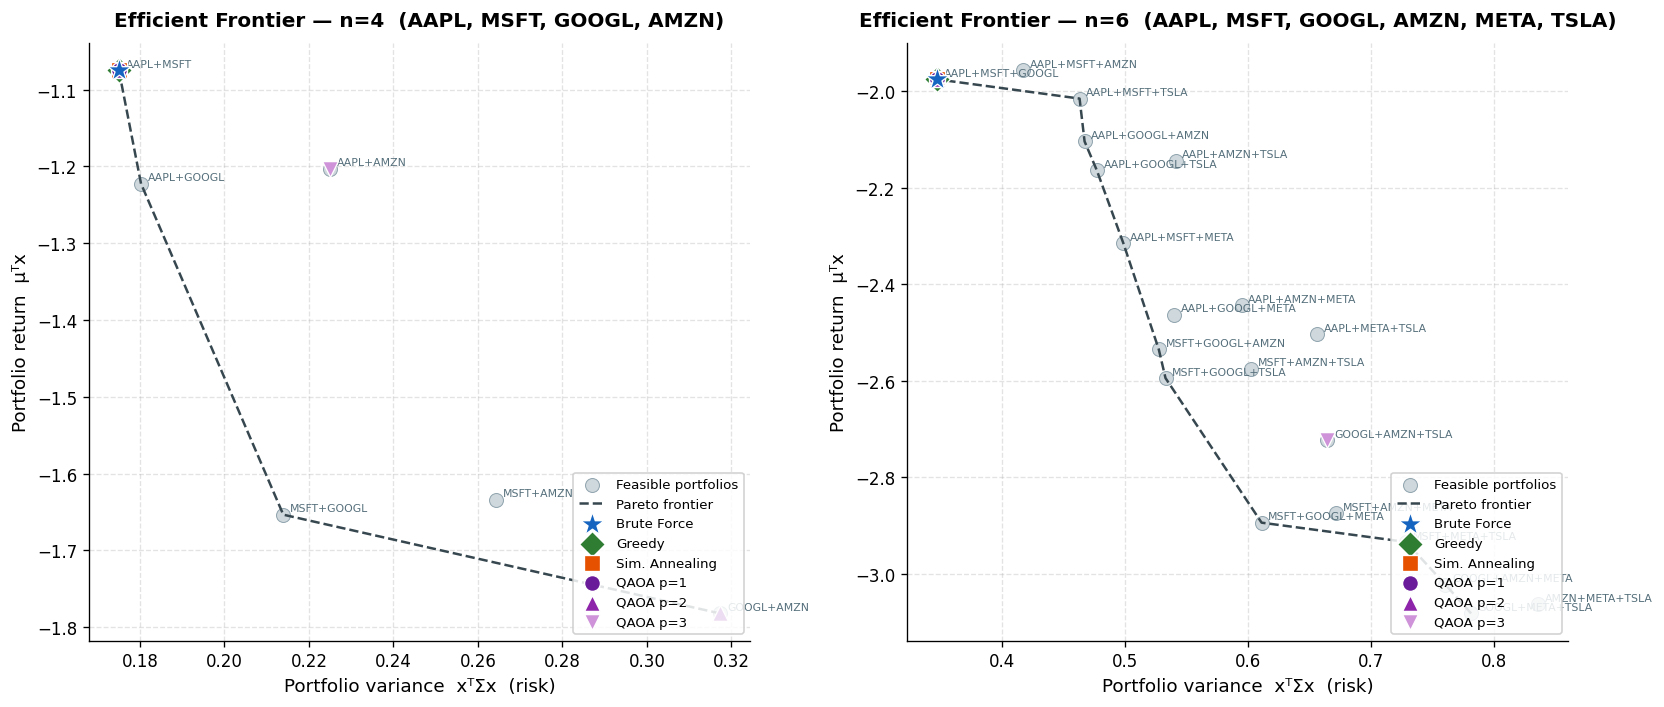

In [5]:
def enumerate_portfolios(mu, Sigma, k, tickers):
    """Return DataFrame of all C(n,k) portfolios with return, variance."""
    n = len(mu)
    rows = []
    for selected in combinations(range(n), k):
        x = np.zeros(n)
        x[list(selected)] = 1.0
        rows.append({
            "bitstring": "".join(str(int(b)) for b in x),
            "stocks": "+".join(tickers[i] for i in selected),
            "ret": float(mu @ x),
            "var": float(x @ Sigma @ x),
        })
    return pd.DataFrame(rows)


def pareto_frontier(port_df):
    """Return Pareto-optimal (min variance) points sorted by return."""
    df_s = port_df.sort_values("ret")
    min_var = np.inf
    pareto = []
    for _, row in df_s.iterrows():
        if row["var"] <= min_var:
            min_var = row["var"]
            pareto.append(row)
    return pd.DataFrame(pareto)


# Load data
tickers_4 = np.array(DEFAULT_TICKERS[:4])
tickers_6 = np.array(DEFAULT_TICKERS[:6])
mu4, Sigma4 = load_assets(list(tickers_4), REPO_ROOT / "data")
mu6, Sigma6 = load_assets(list(tickers_6), REPO_ROOT / "data")

front4 = enumerate_portfolios(mu4, Sigma4, 2, tickers_4)
front6 = enumerate_portfolios(mu6, Sigma6, 3, tickers_6)

# Solver markers: (marker, size, zorder, label, color)
SOLVER_MARKERS = [
    ("brute_force", None, "*", 220, 6, "Brute Force", "#1565C0"),
    ("greedy",      None, "D", 120, 5, "Greedy",      "#2E7D32"),
    ("simulated_annealing", None, "s", 100, 5, "Sim. Annealing", "#E65100"),
    ("qaoa_aer",    1,    "o",  90, 5, "QAOA p=1",    "#6A1B9A"),
    ("qaoa_aer",    2,    "^",  90, 5, "QAOA p=2",    "#8E24AA"),
    ("qaoa_aer",    3,    "v",  90, 5, "QAOA p=3",    "#CE93D8"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, n, front, tickers in zip(axes, [4, 6], [front4, front6], [tickers_4, tickers_6]):
    # All feasible portfolios
    ax.scatter(
        front["var"], front["ret"],
        color="#CFD8DC", s=70, zorder=2, label="Feasible portfolios",
        edgecolors="#90A4AE", linewidth=0.6,
    )
    for _, row in front.iterrows():
        ax.annotate(
            row["stocks"], (row["var"], row["ret"]),
            fontsize=6.5, ha="left", color="#546E7A",
            textcoords="offset points", xytext=(4, 2),
        )

    # Pareto frontier curve
    pf = pareto_frontier(front)
    if len(pf) > 1:
        ax.plot(
            pf["var"], pf["ret"],
            color="#37474F", linestyle="--", linewidth=1.5,
            zorder=3, label="Pareto frontier",
        )

    # Solver solutions
    n_df = df[df["n"] == n]
    for solver, p_val, marker, size, zo, label, color in SOLVER_MARKERS:
        sub = n_df[n_df["solver"] == solver]
        if p_val is not None:
            sub = sub[sub["p"] == p_val]
        if sub.empty:
            continue
        row = sub.iloc[0]
        ax.scatter(
            row["portfolio_variance"], row["portfolio_return"],
            marker=marker, s=size, color=color, zorder=zo,
            edgecolors="white", linewidth=0.8, label=label,
        )

    ax.set_xlabel("Portfolio variance  xᵀΣx  (risk)", fontsize=11)
    ax.set_ylabel("Portfolio return  μᵀx", fontsize=11)
    ax.set_title(f"Efficient Frontier — n={n}  ({', '.join(tickers)})", fontweight="bold", pad=10)
    ax.legend(fontsize=8, framealpha=0.85, loc="lower right")
    ax.grid(linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "fig4_efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()